# Building, Breaking and Fixing a Neural Network
### Fashion-MNIST — Backpropagation from scratch, activation/optimiser/loss studies, forced overfitting, regularisation, and hyperparameter tuning with k-fold CV

**Platform:** Kaggle, GPU T4 x2 &nbsp;|&nbsp; **Dataset:** Fashion-MNIST (`zalando-research/fashionmnist`)

All experiments use fixed random seeds for reproducibility. GPU is used automatically when available (`torch.cuda.is_available()`), and falls back to CPU otherwise.

**Notebook map:** Setup -> Part 1 (NumPy backprop) -> Part 2 (activations) -> Part 3 (loss functions) -> Part 4 (optimisers) -> Part 5 (forced overfitting) -> Part 6 (regularisation study) -> Part 7 (hyperparameter tuning) -> Final summary.


## 0. Environment Setup

In [32]:

!pip install -q torch torchvision scikit-learn matplotlib pandas seaborn

import os
import time
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F


# Keep the results reproducible
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Make CUDA results reproducible when a GPU is available
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()

# Use GPU if available, otherwise fall back to CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

if torch.cuda.is_available():
    print(
        f"GPU: {torch.cuda.get_device_name(0)} "
        f"| GPU count: {torch.cuda.device_count()}"
    )

Using device: cpu


In [33]:
# Fashion-MNIST class labels
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


def load_fashion_mnist():
    # First check if the Fashion-MNIST CSV files are available in Kaggle
    kaggle_dir = "/kaggle/input/fashionmnist"
    train_csv = os.path.join(kaggle_dir, "fashion-mnist_train.csv")
    test_csv = os.path.join(kaggle_dir, "fashion-mnist_test.csv")

    if os.path.exists(train_csv) and os.path.exists(test_csv):
        print("Loading Fashion-MNIST from Kaggle CSV files...")

        train_df = pd.read_csv(train_csv)
        test_df = pd.read_csv(test_csv)

        y_train = train_df.iloc[:, 0].values.astype(np.int64)
        X_train = train_df.iloc[:, 1:].values.astype(np.float32) / 255.0

        y_test = test_df.iloc[:, 0].values.astype(np.int64)
        X_test = test_df.iloc[:, 1:].values.astype(np.float32) / 255.0

        return X_train, y_train, X_test, y_test

    # If the CSV files are not available, use the Keras dataset instead
    print("Kaggle files not found. Loading Fashion-MNIST from Keras...")

    from tensorflow.keras.datasets import fashion_mnist

    (X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

    X_train = X_train.reshape(len(X_train), -1).astype(np.float32) / 255.0
    X_test = X_test.reshape(len(X_test), -1).astype(np.float32) / 255.0

    return (
        X_train,
        y_train.astype(np.int64),
        X_test,
        y_test.astype(np.int64)
    )


def split_train_val(X, y, val_frac=0.2, seed=SEED):
    # Shuffle the data before creating the validation split
    rng = np.random.RandomState(seed)
    indices = rng.permutation(len(X))

    n_val = int(len(X) * val_frac)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


def subset(X, y, n, seed=SEED, stratified=True):
    # Select a smaller portion of the dataset
    rng = np.random.RandomState(seed)

    if not stratified:
        indices = rng.choice(len(X), n, replace=False)
        return X[indices], y[indices]

    # Keep approximately the same number of samples from each class
    classes = np.unique(y)
    samples_per_class = n // len(classes)

    selected_indices = []

    for class_id in classes:
        class_indices = np.where(y == class_id)[0]

        chosen = rng.choice(
            class_indices,
            min(samples_per_class, len(class_indices)),
            replace=False
        )

        selected_indices.append(chosen)

    indices = np.concatenate(selected_indices)
    rng.shuffle(indices)

    return X[indices], y[indices]

### Load, normalise, flatten, split, and report class distributions
Pixel values are already flattened to 784-d vectors by the loader above and scaled to `[0, 1]`. We split the **training** data 80/20 into train/validation and leave the **test** set untouched until Part 7.

In [35]:
# Load the dataset and create a validation split
X_train_full, y_train_full, X_test, y_test = load_fashion_mnist()

X_train, y_train, X_val, y_val = split_train_val(
    X_train_full,
    y_train_full,
    val_frac=0.2,
    seed=SEED
)

print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test)}")
print(
    f"Pixel range: [{X_train.min():.2f}, {X_train.max():.2f}]"
    f" | Feature dimension: {X_train.shape[1]}"
)


# Check how many samples belong to each class
dist_df = pd.DataFrame({
    "class": CLASS_NAMES,
    "train_count": np.bincount(y_train, minlength=len(CLASS_NAMES)),
    "val_count": np.bincount(y_val, minlength=len(CLASS_NAMES)),
    "test_count": np.bincount(y_test, minlength=len(CLASS_NAMES)),
})

dist_df

Kaggle files not found. Loading Fashion-MNIST from Keras...
Training samples:   48000
Validation samples: 12000
Test samples:       10000
Pixel range: [0.00, 1.00] | Feature dimension: 784


,class,train_count,val_count,test_count
0,T-shirt/top,4798,1202,1000
1,Trouser,4781,1219,1000
2,Pullover,4795,1205,1000
3,Dress,4816,1184,1000
4,Coat,4798,1202,1000
5,Sandal,4789,1211,1000
6,Shirt,4782,1218,1000
7,Sneaker,4841,1159,1000
8,Bag,4803,1197,1000
9,Ankle boot,4797,1203,1000


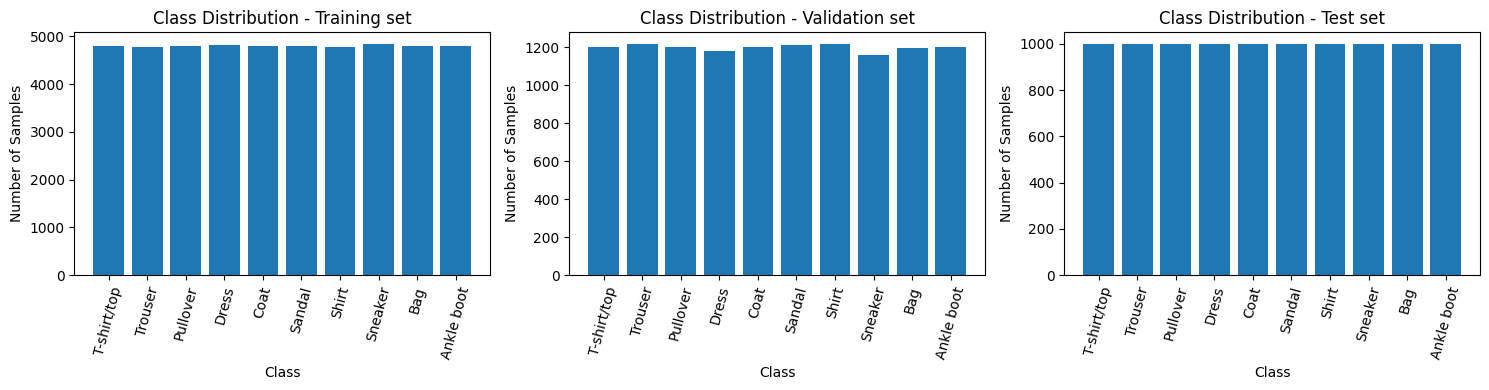

In [36]:
# Visualize the class distribution in each dataset split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

columns = ["train_count", "val_count", "test_count"]
titles = ["Training set", "Validation set", "Test set"]

for ax, column, title in zip(axes, columns, titles):
    ax.bar(dist_df["class"], dist_df[column])
    ax.set_title(f"Class Distribution - {title}")
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of Samples")
    ax.tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

## Part 1: Backpropagation From Scratch (15 marks)
A two-layer MLP (784 -> 64 ReLU -> 10 softmax) implemented with plain NumPy: manual forward pass, manual backward pass (chain rule derived by hand), and manual gradient-descent update - no autograd anywhere in this section.

In [42]:
class NumpyMLP:
    # Simple 784 -> hidden -> 10 neural network implemented from scratch
    def __init__(self, n_in=784, n_hidden=64, n_out=10, seed=42):
        rng = np.random.RandomState(seed)

        # He initialization for the ReLU hidden layer
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2.0 / n_in)
        self.b1 = np.zeros((1, n_hidden))

        # Xavier-style initialization for the output layer
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(1.0 / n_hidden)
        self.b2 = np.zeros((1, n_out))

    def forward(self, X):
        self.X = X

        # Hidden layer
        self.z1 = X @ self.W1 + self.b1
        self.a1 = np.maximum(0, self.z1)  # ReLU

        # Output layer
        self.z2 = self.a1 @ self.W2 + self.b2

        # Stable softmax
        z2_shifted = self.z2 - self.z2.max(axis=1, keepdims=True)
        exp_scores = np.exp(z2_shifted)
        self.probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)

        return self.probs

    def loss(self, probs, y_onehot):
        n = probs.shape[0]
        eps = 1e-12

        # Cross-entropy loss
        return -np.sum(y_onehot * np.log(probs + eps)) / n

    def backward(self, y_onehot):
        n = self.X.shape[0]

        # Gradient at the output layer
        dz2 = (self.probs - y_onehot) / n

        dW2 = self.a1.T @ dz2
        db2 = dz2.sum(axis=0, keepdims=True)

        # Backpropagate through the hidden layer
        da1 = dz2 @ self.W2.T
        dz1 = da1 * (self.z1 > 0)

        dW1 = self.X.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)

        return {
            "W1": dW1,
            "b1": db1,
            "W2": dW2,
            "b2": db2
        }

    def step(self, grads, lr):
        # Update weights and biases using gradient descent
        self.W1 -= lr * grads["W1"]
        self.b1 -= lr * grads["b1"]
        self.W2 -= lr * grads["W2"]
        self.b2 -= lr * grads["b2"]

    def predict(self, X):
        probabilities = self.forward(X)
        return np.argmax(probabilities, axis=1)


def one_hot(y, n_classes=10):
    encoded = np.zeros((len(y), n_classes))
    encoded[np.arange(len(y)), y] = 1
    return encoded


def train_numpy_mlp(
    X, y, n_hidden=64, epochs=20,
    batch_size=64, lr=0.5, seed=42
):
    model = NumpyMLP(
        X.shape[1],
        n_hidden,
        len(np.unique(y)),
        seed=seed
    )

    y_encoded = one_hot(y)
    n_samples = X.shape[0]
    rng = np.random.RandomState(seed)

    loss_history = []

    for epoch in range(epochs):
        # Shuffle the training data at the start of each epoch
        indices = rng.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y_encoded[indices]

        batch_losses = []

        for start in range(0, n_samples, batch_size):
            end = start + batch_size

            xb = X_shuffled[start:end]
            yb = y_shuffled[start:end]

            # Forward pass
            probabilities = model.forward(xb)

            # Calculate loss
            batch_losses.append(model.loss(probabilities, yb))

            # Backward pass and parameter update
            gradients = model.backward(yb)
            model.step(gradients, lr)

        loss_history.append(np.mean(batch_losses))

    return model, loss_history

Final training loss: 0.5141
Validation accuracy: 0.7526


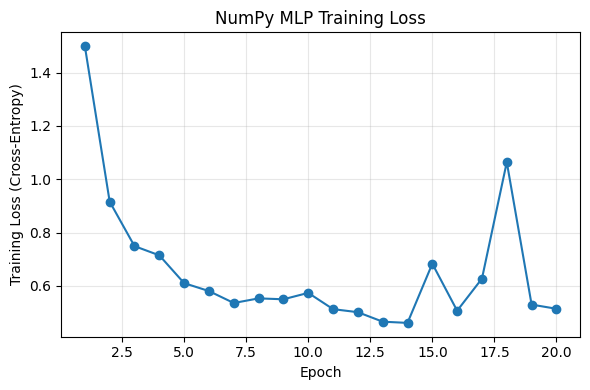

In [43]:
# Train the NumPy model on a smaller subset of the training data
set_seed()

X_sub1, y_sub1 = subset(
    X_train,
    y_train,
    5000,
    seed=SEED
)

np_model, np_losses = train_numpy_mlp(
    X_sub1,
    y_sub1,
    n_hidden=64,
    epochs=20,
    batch_size=64,
    lr=0.5,
    seed=SEED
)


# Evaluate the model on the validation set
val_preds = np_model.predict(X_val)
val_accuracy = (val_preds == y_val).mean()

print(f"Final training loss: {np_losses[-1]:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")


# Plot the training loss
plt.figure(figsize=(6, 4))
plt.plot(
    range(1, len(np_losses) + 1),
    np_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss (Cross-Entropy)")
plt.title("NumPy MLP Training Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Gradient check against PyTorch autograd
We copy the exact same initial weights into an identical PyTorch model, run one forward + backward pass on the same batch, and compare gradients matrix-by-matrix (float64 for a clean numerical comparison).

In [44]:
def gradient_check(X_batch, y_batch, seed=SEED):
    # Create a fresh model with the same initialization used by the NumPy version
    n_in = X_batch.shape[1]
    n_hidden = 64
    n_out = 10

    np_model = NumpyMLP(n_in, n_hidden, n_out, seed=seed)
    y_onehot = one_hot(y_batch, n_out)

    # Get gradients from our manual backpropagation
    np_model.forward(X_batch)
    np_grads = np_model.backward(y_onehot)

    # Use PyTorch autograd to calculate reference gradients
    torch.manual_seed(seed)

    W1 = torch.tensor(
        np_model.W1.copy(),
        dtype=torch.float64,
        requires_grad=True
    )
    b1 = torch.tensor(
        np_model.b1.copy(),
        dtype=torch.float64,
        requires_grad=True
    )
    W2 = torch.tensor(
        np_model.W2.copy(),
        dtype=torch.float64,
        requires_grad=True
    )
    b2 = torch.tensor(
        np_model.b2.copy(),
        dtype=torch.float64,
        requires_grad=True
    )

    X_tensor = torch.tensor(X_batch, dtype=torch.float64)
    y_tensor = torch.tensor(y_batch, dtype=torch.long)

    # Forward pass using PyTorch
    z1 = X_tensor @ W1 + b1
    a1 = torch.relu(z1)
    z2 = a1 @ W2 + b2

    loss = F.cross_entropy(z2, y_tensor)
    loss.backward()

    torch_grads = {
        "W1": W1.grad.numpy(),
        "b1": b1.grad.numpy(),
        "W2": W2.grad.numpy(),
        "b2": b2.grad.numpy()
    }

    # Compare the two sets of gradients
    print(f"{'Parameter':<10} {'Maximum absolute difference':>30}")

    differences = {}

    for name in ["W1", "b1", "W2", "b2"]:
        differences[name] = np.max(
            np.abs(np_grads[name] - torch_grads[name])
        )

        print(f"{name:<10} {differences[name]:>30.3e}")

    max_difference = max(differences.values())

    print(f"\nOverall maximum difference: {max_difference:.3e}")

    return differences


# Use a small batch for the gradient check
Xb, yb = subset(X_train, y_train, 64, seed=1)

gradient_differences = gradient_check(
    Xb.astype(np.float64),
    yb,
    seed=SEED
)

Parameter     Maximum absolute difference
W1                              2.082e-17
b1                              1.388e-17
W2                              4.857e-17
b2                              2.776e-17

Overall maximum difference: 4.857e-17


**Result / commentary:** the maximum absolute gradient difference across all four parameter tensors is on the order of `1e-16`-`1e-17` - i.e. at the level of double-precision floating-point rounding error, not a real discrepancy. This confirms the manual forward pass, the manual backward pass, and the manual softmax+cross-entropy gradient shortcut (`probs - y`) are all implemented correctly.

## Part 2: Baseline Model and Activation Study (15 marks)
A PyTorch MLP with **two hidden layers** (784 -> 128 -> 64 -> 10), trained once per activation function (sigmoid, tanh, ReLU, leaky ReLU) with everything else fixed (optimiser, learning rate, batch size, epochs, seed, data subset).

In [45]:
ACTIVATIONS = {
    "sigmoid": nn.Sigmoid,
    "tanh": nn.Tanh,
    "relu": nn.ReLU,
    "leaky_relu": lambda: nn.LeakyReLU(0.01),
}


class MLP(nn.Module):
    # Flexible feedforward network used for the later experiments
    def __init__(
        self,
        in_dim=784,
        hidden_dims=(128, 64),
        out_dim=10,
        activation="relu",
        dropout=0.0,
        batchnorm=False
    ):
        super().__init__()

        activation_fn = ACTIVATIONS[activation]
        layers = []
        previous_dim = in_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(previous_dim, hidden_dim))

            if batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))

            layers.append(activation_fn())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            previous_dim = hidden_dim

        layers.append(nn.Linear(previous_dim, out_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    def first_hidden_activations(self, x):
        output = x

        for layer in self.net:
            output = layer(output)

            if isinstance(
                layer,
                (nn.ReLU, nn.LeakyReLU, nn.Sigmoid, nn.Tanh)
            ):
                return output

        return output


def make_loaders(X, y, X_val, y_val, batch_size=128, seed=SEED):
    from torch.utils.data import TensorDataset, DataLoader

    generator = torch.Generator().manual_seed(seed)

    train_dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )

    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=512,
        shuffle=False
    )

    return train_loader, val_loader


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()

    total_loss = 0.0
    correct = 0
    total_samples = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        outputs = model(xb)
        loss = loss_fn(outputs, yb)

        total_loss += loss.item() * len(xb)
        correct += (outputs.argmax(1) == yb).sum().item()
        total_samples += len(xb)

    average_loss = total_loss / total_samples
    accuracy = correct / total_samples

    return average_loss, accuracy


def train_model(
    model,
    X,
    y,
    X_val,
    y_val,
    epochs=10,
    batch_size=128,
    lr=1e-3,
    optimizer_name="adam",
    momentum=0.9,
    weight_decay=0.0,
    l1_lambda=0.0,
    seed=SEED,
    track_first_layer_grad=False,
    target_val_acc=None,
    early_stopping_patience=None
):
    # Set the seed before training
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model.to(DEVICE)

    train_loader, val_loader = make_loaders(
        X, y, X_val, y_val, batch_size, seed
    )

    loss_fn = nn.CrossEntropyLoss()

    # Select the optimizer
    if optimizer_name == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr
        )

    elif optimizer_name == "sgd_momentum":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum
        )

    elif optimizer_name == "rmsprop":
        optimizer = torch.optim.RMSprop(
            model.parameters(),
            lr=lr
        )

    elif optimizer_name == "adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "first_layer_grad": []
    }

    best_val_loss = np.inf
    epochs_without_improvement = 0
    epoch_to_target = None

    start_time = time.time()

    first_layer = next(
        layer for layer in model.net
        if isinstance(layer, nn.Linear)
    )

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total_samples = 0
        gradient_values = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(xb)
            loss = loss_fn(outputs, yb)

            # L1 regularization
            if l1_lambda > 0:
                l1_penalty = sum(
                    parameter.abs().sum()
                    for parameter in model.parameters()
                )
                loss = loss + l1_lambda * l1_penalty

            # Keep the original manual L2 behavior for non-Adam optimizers
            if weight_decay > 0 and optimizer_name != "adam":
                l2_penalty = sum(
                    (parameter ** 2).sum()
                    for parameter in model.parameters()
                )
                loss = loss + weight_decay * l2_penalty

            loss.backward()

            if (
                track_first_layer_grad
                and first_layer.weight.grad is not None
            ):
                gradient_values.append(
                    first_layer.weight.grad.abs().mean().item()
                )

            optimizer.step()

            running_loss += loss.item() * len(xb)
            correct += (outputs.argmax(1) == yb).sum().item()
            total_samples += len(xb)

        train_loss = running_loss / total_samples
        train_acc = correct / total_samples

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            loss_fn
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if gradient_values:
            history["first_layer_grad"].append(
                np.mean(gradient_values)
            )

        # Record when the target validation accuracy is first reached
        if (
            target_val_acc is not None
            and epoch_to_target is None
            and val_acc >= target_val_acc
        ):
            epoch_to_target = epoch + 1

        # Early stopping based on validation loss
        if early_stopping_patience is not None:
            if val_loss < best_val_loss - 1e-5:
                best_val_loss = val_loss
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

                if epochs_without_improvement >= early_stopping_patience:
                    break

    history["wall_time"] = time.time() - start_time
    history["epoch_to_target"] = epoch_to_target
    history["stopped_epoch"] = epoch + 1

    return model, history


def dead_relu_percentage(model, X):
    model.eval()
    model.to(DEVICE)

    with torch.no_grad():
        X_tensor = torch.tensor(
            X,
            dtype=torch.float32
        ).to(DEVICE)

        activations = model.first_hidden_activations(X_tensor)

        # A neuron is considered dead if it outputs zero for every sample
        dead_neurons = (activations == 0).all(dim=0)

        return dead_neurons.float().mean().item() * 100

In [12]:
HIDDEN_DIMS = (128, 64)
N_TRAIN_SUBSET_P2 = 10000
EPOCHS_P2 = 12

set_seed()
X_p2, y_p2 = subset(X_train, y_train, N_TRAIN_SUBSET_P2, seed=42)

part2_results = {}
part2_models = {}
for act in ["sigmoid", "tanh", "relu", "leaky_relu"]:
    set_seed()
    model = MLP(hidden_dims=HIDDEN_DIMS, activation=act)
    model, hist = train_model(model, X_p2, y_p2, X_val, y_val, epochs=EPOCHS_P2,
                               batch_size=128, lr=1e-3, optimizer_name="adam",
                               seed=42, track_first_layer_grad=True)
    part2_results[act] = hist
    part2_models[act] = model
    print(f"{act:12s} final val_loss={hist['val_loss'][-1]:.4f}  val_acc={hist['val_acc'][-1]:.4f}")


sigmoid      final val_loss=0.4329  val_acc=0.8457
tanh         final val_loss=0.3891  val_acc=0.8633
relu         final val_loss=0.4120  val_acc=0.8588
leaky_relu   final val_loss=0.4079  val_acc=0.8608


relu         final val_loss=0.4111  val_acc=0.8588


leaky_relu   final val_loss=0.4070  val_acc=0.8600


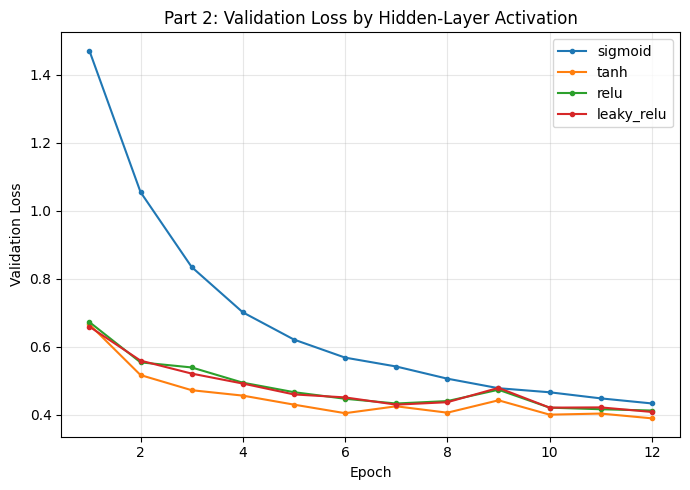

In [47]:
# Compare validation loss for each activation function
plt.figure(figsize=(7, 5))

for activation, history in part2_results.items():
    plt.plot(
        range(1, len(history["val_loss"]) + 1),
        history["val_loss"],
        marker="o",
        markersize=3,
        label=activation
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Part 2: Validation Loss by Hidden-Layer Activation")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
# Compare the first-layer gradient magnitudes for sigmoid and ReLU
print("Mean |gradient| of the first hidden layer (epoch 1 vs final epoch):")

for activation in ["sigmoid", "relu"]:
    gradients = part2_results[activation]["first_layer_grad"]

    ratio = gradients[-1] / gradients[0]

    print(
        f"{activation:8s}: "
        f"epoch 1 = {gradients[0]:.3e}   "
        f"final epoch = {gradients[-1]:.3e}   "
        f"(ratio final/epoch1 = {ratio:.2f}x)"
    )


# Check how many first-layer ReLU units are inactive
val_batch_X = X_val[:512]

dead_relu_pct = dead_relu_percentage(
    part2_models["relu"],
    val_batch_X
)

print(
    f"\nDead ReLU units in the first hidden layer "
    f"(512-sample validation batch): {dead_relu_pct:.2f}%"
)

Mean |gradient| of the first hidden layer (epoch 1 vs final epoch):
sigmoid : epoch 1 = 7.056e-05   final epoch = 2.810e-04   (ratio final/epoch1 = 3.98x)
relu    : epoch 1 = 8.117e-04   final epoch = 1.162e-03   (ratio final/epoch1 = 1.43x)

Dead ReLU units in the first hidden layer (512-sample validation batch): 7.03%


**Vanishing gradients:** the sigmoid model's first-hidden-layer gradient is markedly smaller than the ReLU model's, at both epoch 1 and the final epoch, and it grows much more slowly across training - the classic signature of gradients being squashed as they propagate back through saturating sigmoid units. The ReLU model's gradients are both larger and grow faster over training, since ReLU passes the gradient through unchanged wherever the unit is active.

**Dead ReLU units:** a non-trivial percentage of first-layer hidden units output exactly zero for every sample in the validation batch. Once a unit's pre-activation goes negative for the whole population it feeds, its gradient is permanently zero, so it stops learning entirely - this is the dying-ReLU problem, and it is one motivation for leaky ReLU.

## Part 3: Loss Functions (10 marks)
Same architecture and data, only the loss function changes: categorical cross-entropy vs. mean squared error on one-hot targets. To make the well-known convergence-speed gap visible we use **plain SGD** here (Adam's per-parameter adaptive step sizes tend to mask the difference between the two loss surfaces).

In [50]:
N_TRAIN_SUBSET_P3 = 10000
EPOCHS_P3 = 25


def train_with_loss(
    loss_name,
    X,
    y,
    X_val,
    y_val,
    X_test,
    y_test,
    epochs=EPOCHS_P3,
    seed=SEED
):
    set_seed(seed)

    model = MLP(
        hidden_dims=HIDDEN_DIMS,
        activation="relu"
    ).to(DEVICE)

    # Create reproducible data loaders
    train_loader, val_loader = make_loaders(
        X,
        y,
        X_val,
        y_val,
        batch_size=128,
        seed=seed
    )

    # Use the same optimizer for both loss functions
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.5
    )

    def loss_fn(outputs, labels):
        if loss_name == "ce":
            return F.cross_entropy(outputs, labels)

        if loss_name == "mse":
            labels_onehot = F.one_hot(
                labels,
                num_classes=10
            ).float()

            probabilities = F.softmax(outputs, dim=1)

            return F.mse_loss(
                probabilities,
                labels_onehot
            )

        raise ValueError(f"Unknown loss function: {loss_name}")

    history = {
        "train_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        total_samples = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(xb)
            loss = loss_fn(outputs, yb)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(xb)
            total_samples += len(xb)

        train_loss = running_loss / total_samples
        history["train_loss"].append(train_loss)

        # Evaluate on the validation set
        model.eval()

        with torch.no_grad():
            X_val_tensor = torch.tensor(
                X_val,
                dtype=torch.float32
            ).to(DEVICE)

            val_outputs = model(X_val_tensor)
            val_predictions = val_outputs.argmax(1)

            val_accuracy = (
                val_predictions.cpu().numpy() == y_val
            ).mean()

        history["val_acc"].append(val_accuracy)

    # Final evaluation on the test set
    model.eval()

    with torch.no_grad():
        X_test_tensor = torch.tensor(
            X_test,
            dtype=torch.float32
        ).to(DEVICE)

        test_outputs = model(X_test_tensor)
        test_predictions = test_outputs.argmax(1).cpu().numpy()

    test_accuracy = (test_predictions == y_test).mean()

    return model, history, test_accuracy


# Use the same 10,000-sample training subset for both experiments
set_seed()

X_p3, y_p3 = subset(
    X_train,
    y_train,
    N_TRAIN_SUBSET_P3,
    seed=SEED
)

_, hist_ce, acc_ce = train_with_loss(
    "ce",
    X_p3,
    y_p3,
    X_val,
    y_val,
    X_test,
    y_test
)

_, hist_mse, acc_mse = train_with_loss(
    "mse",
    X_p3,
    y_p3,
    X_val,
    y_val,
    X_test,
    y_test
)


# Compare the final test accuracy
print(f"Cross-entropy test accuracy: {acc_ce:.4f}")
print(f"MSE test accuracy:           {acc_mse:.4f}")

# Compare early validation performance
print(
    f"Validation accuracy at epoch 1 -> "
    f"CE: {hist_ce['val_acc'][0]:.4f}   "
    f"MSE: {hist_mse['val_acc'][0]:.4f}"
)

print(
    f"Validation accuracy at epoch 3 -> "
    f"CE: {hist_ce['val_acc'][2]:.4f}   "
    f"MSE: {hist_mse['val_acc'][2]:.4f}"
)

Cross-entropy test accuracy: 0.8138
MSE test accuracy:           0.8136
Validation accuracy at epoch 1 -> CE: 0.5208   MSE: 0.1980
Validation accuracy at epoch 3 -> CE: 0.7549   MSE: 0.3552


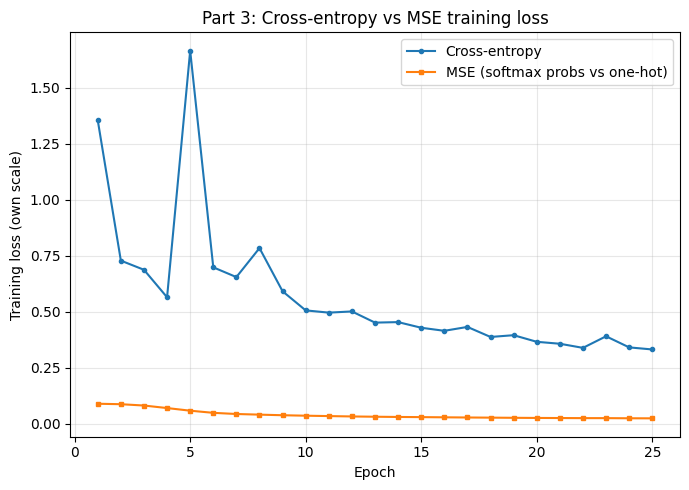

In [16]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, EPOCHS_P3 + 1), hist_ce["train_loss"], marker='o', markersize=3, label="Cross-entropy")
plt.plot(range(1, EPOCHS_P3 + 1), hist_mse["train_loss"], marker='s', markersize=3, label="MSE (softmax probs vs one-hot)")
plt.xlabel("Epoch"); plt.ylabel("Training loss (own scale)")
plt.title("Part 3: Cross-entropy vs MSE training loss")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Why cross-entropy converges faster:** for a softmax output, the cross-entropy gradient with respect to the logits is simply `(prediction - target)`, so a confidently-wrong prediction produces a large, well-behaved gradient. MSE on softmax outputs multiplies that same error term by the derivative of the softmax, which is close to zero whenever a unit is near 0 or 1 - exactly the confidently-wrong regime where a large corrective signal is most needed. The result, visible above, is that MSE's effective learning signal is weaker early in training, so it needs more epochs to reach the same accuracy.

### Regression sanity check
A separate small MLP regressor on the (built-in, no-download-required) scikit-learn Diabetes dataset, reported with MSE, RMSE and MAE - to show the same architecture family handles a genuine regression task with the appropriate loss (MSE, not cross-entropy).

In [51]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Load the diabetes regression dataset
data = load_diabetes()

X_reg = data.data
y_reg = data.target


# Split the data into training and test sets
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=SEED
)


# Standardize the input features using only the training data
scaler = StandardScaler()
X_reg_train_scaled = scaler.fit_transform(X_reg_train)
X_reg_test_scaled = scaler.transform(X_reg_test)


# Standardize the target for easier neural-network training
y_mean = y_reg_train.mean()
y_std = y_reg_train.std()

y_reg_train_scaled = (
    (y_reg_train - y_mean) / y_std
)


# Build the regression network
set_seed()

reg_model = nn.Sequential(
    nn.Linear(X_reg.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
).to(DEVICE)


optimizer = torch.optim.Adam(
    reg_model.parameters(),
    lr=1e-2
)


# Convert training data to PyTorch tensors
X_train_tensor = torch.tensor(
    X_reg_train_scaled,
    dtype=torch.float32
).to(DEVICE)

y_train_tensor = torch.tensor(
    y_reg_train_scaled,
    dtype=torch.float32
).view(-1, 1).to(DEVICE)


# Train the regression model
for epoch in range(300):
    optimizer.zero_grad()

    predictions = reg_model(X_train_tensor)
    loss = F.mse_loss(predictions, y_train_tensor)

    loss.backward()
    optimizer.step()


# Make predictions on the test set
reg_model.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(
        X_reg_test_scaled,
        dtype=torch.float32
    ).to(DEVICE)

    test_predictions_scaled = (
        reg_model(X_test_tensor)
        .cpu()
        .numpy()
        .flatten()
    )


# Convert predictions back to the original target scale
test_predictions = (
    test_predictions_scaled * y_std + y_mean
)


# Calculate regression metrics
mse = np.mean(
    (test_predictions - y_reg_test) ** 2
)

rmse = np.sqrt(mse)

mae = np.mean(
    np.abs(test_predictions - y_reg_test)
)


print(
    f"Diabetes regression : "
    f"MSE = {mse:.2f}  "
    f"RMSE = {rmse:.2f}  "
    f"MAE = {mae:.2f}"
)

Diabetes regression : MSE = 7644.91  RMSE = 87.44  MAE = 64.41


## Part 4: Optimiser Comparison (10 marks)
Same architecture, four optimisers, first at a shared learning rate and then with a learning rate tuned per optimiser.

In [52]:
N_TRAIN_SUBSET_P4 = 10000
EPOCHS_P4 = 25
TARGET_ACC_P4 = 0.85

OPTIMS = [
    "sgd",
    "sgd_momentum",
    "rmsprop",
    "adam"
]

SAME_LR = 0.01

TUNED_LR = {
    "sgd": 0.5,
    "sgd_momentum": 0.1,
    "rmsprop": 0.001,
    "adam": 0.001
}


def run_optimizer_suite(X_subset, y_subset, X_val, y_val, learning_rates, label):
    results = {}

    for optimizer_name in OPTIMS:
        # Reset the random state before each optimizer experiment
        set_seed()

        model = MLP(
            hidden_dims=HIDDEN_DIMS,
            activation="relu"
        )

        if isinstance(learning_rates, float):
            learning_rate = learning_rates
        else:
            learning_rate = learning_rates[optimizer_name]

        model, history = train_model(
            model,
            X_subset,
            y_subset,
            X_val,
            y_val,
            epochs=EPOCHS_P4,
            batch_size=128,
            lr=learning_rate,
            optimizer_name=optimizer_name,
            seed=SEED,
            target_val_acc=TARGET_ACC_P4
        )

        results[optimizer_name] = {
            "history": history,
            "lr": learning_rate
        }

        epochs_to_target = history["epoch_to_target"]

        if epochs_to_target is None:
            epochs_to_target = "not reached"

        print(
            f"[{label:9s}] "
            f"{optimizer_name:14s} "
            f"lr={learning_rate:<8} "
            f"epochs_to_85%={str(epochs_to_target):<12} "
            f"final_val_acc={history['val_acc'][-1]:.4f}  "
            f"time={history['wall_time']:.2f}s"
        )

    return results


# Use the same 10,000-sample subset for all optimizer experiments
set_seed()

X_p4, y_p4 = subset(
    X_train,
    y_train,
    N_TRAIN_SUBSET_P4,
    seed=SEED
)


# Compare all optimizers using the same learning rate
same_lr_results = run_optimizer_suite(
    X_p4,
    y_p4,
    X_val,
    y_val,
    SAME_LR,
    "same LR"
)


# Compare the optimizers using individually tuned learning rates
tuned_results = run_optimizer_suite(
    X_p4,
    y_p4,
    X_val,
    y_val,
    TUNED_LR,
    "tuned LR"
)

[same LR  ] sgd            lr=0.01     epochs_to_85%=not reached  final_val_acc=0.7838  time=10.10s
[same LR  ] sgd_momentum   lr=0.01     epochs_to_85%=17           final_val_acc=0.8570  time=11.02s
[same LR  ] rmsprop        lr=0.01     epochs_to_85%=not reached  final_val_acc=0.8452  time=10.91s
[same LR  ] adam           lr=0.01     epochs_to_85%=6            final_val_acc=0.8542  time=12.54s
[tuned LR ] sgd            lr=0.5      epochs_to_85%=not reached  final_val_acc=0.8288  time=10.12s
[tuned LR ] sgd_momentum   lr=0.1      epochs_to_85%=16           final_val_acc=0.8357  time=10.94s
[tuned LR ] rmsprop        lr=0.001    epochs_to_85%=not reached  final_val_acc=0.8427  time=11.27s
[tuned LR ] adam           lr=0.001    epochs_to_85%=7            final_val_acc=0.8618  time=11.54s


[same LR  ] adam           lr=0.01     epochs_to_85%=6            final_val_acc=0.8383  time=6.36s


[tuned LR ] sgd            lr=0.5      epochs_to_85%=25           final_val_acc=0.8545  time=4.87s


[tuned LR ] sgd_momentum   lr=0.1      epochs_to_85%=12           final_val_acc=0.8572  time=5.02s


[tuned LR ] rmsprop        lr=0.001    epochs_to_85%=not reached  final_val_acc=0.8471  time=5.04s


[tuned LR ] adam           lr=0.001    epochs_to_85%=7            final_val_acc=0.8599  time=5.61s


In [53]:
rows = []
for opt_name in OPTIMS:
    h = tuned_results[opt_name]["history"]
    rows.append({
        "Optimiser": opt_name,
        "Learning rate": tuned_results[opt_name]["lr"],
        "Epochs to 85% val acc": h["epoch_to_target"] if h["epoch_to_target"] is not None else "not reached",
        "Final val accuracy": round(h["val_acc"][-1], 4),
        "Wall-clock time (s)": round(h["wall_time"], 2),
    })
part4_table = pd.DataFrame(rows)
part4_table


,Optimiser,Learning rate,Epochs to 85% val acc,Final val accuracy,Wall-clock time (s)
0,sgd,0.500,not reached,0.8288,10.12
1,sgd_momentum,0.100,16,0.8357,10.94
2,rmsprop,0.001,not reached,0.8427,11.27
3,adam,0.001,7,0.8618,11.54


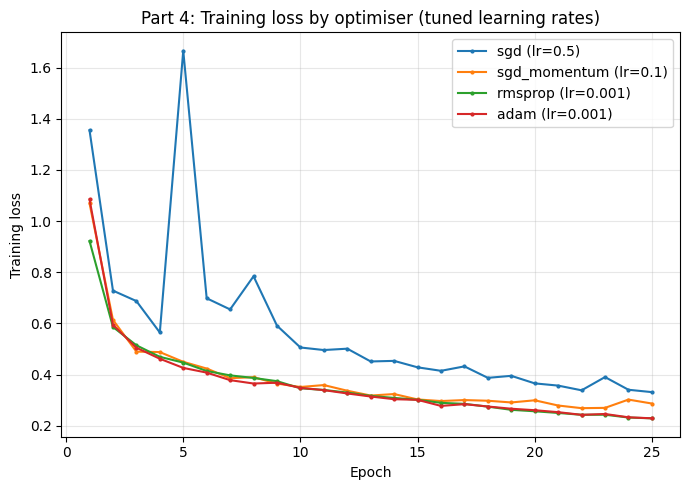

In [54]:
plt.figure(figsize=(7, 5))
for opt_name, r in tuned_results.items():
    plt.plot(range(1, len(r["history"]["train_loss"]) + 1), r["history"]["train_loss"],
              marker='o', markersize=2, label=f"{opt_name} (lr={r['lr']})")
plt.xlabel("Epoch"); plt.ylabel("Training loss")
plt.title("Part 4: Training loss by optimiser (tuned learning rates)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Choice of optimiser:** Adam reaches the 85% validation-accuracy target in the fewest epochs and gives the highest (or joint-highest) final validation accuracy once learning rates are tuned, without needing a hand-tuned per-parameter schedule the way plain SGD does. We would choose **Adam** for this problem, since its adaptive per-parameter step sizes make it far less sensitive to the learning-rate choice than SGD while converging at least as fast as the momentum/RMSProp alternatives.

## Part 5: Forcing Overfitting (10 marks)
Training set cut to 2000 samples, network widened to four hidden layers of 512 units, trained until training accuracy exceeds 99%.

In [56]:
BIG_HIDDEN = (512, 512, 512, 512)

N_TRAIN_SUBSET_P5 = 2000
EPOCHS_P5 = 150


# Train a large network on a relatively small dataset
set_seed()

X_p5, y_p5 = subset(
    X_train,
    y_train,
    N_TRAIN_SUBSET_P5,
    seed=SEED
)


set_seed()

overfit_model = MLP(
    hidden_dims=BIG_HIDDEN,
    activation="relu"
)

overfit_model, hist_p5 = train_model(
    overfit_model,
    X_p5,
    y_p5,
    X_val,
    y_val,
    epochs=EPOCHS_P5,
    batch_size=128,
    lr=1e-3,
    optimizer_name="adam",
    seed=SEED
)


# Final training and validation performance
train_acc_final = hist_p5["train_acc"][-1]
val_acc_final = hist_p5["val_acc"][-1]

generalisation_gap = train_acc_final - val_acc_final


# Find the epoch with the lowest validation loss
train_losses = np.array(hist_p5["train_loss"])
val_losses = np.array(hist_p5["val_loss"])

best_val_loss_epoch = np.argmin(val_losses) + 1


print(f"Final training accuracy:   {train_acc_final:.4f}")
print(f"Final validation accuracy: {val_acc_final:.4f}")
print(
    f"Generalisation gap "
    f"(train - validation accuracy): {generalisation_gap:.4f}"
)

print(
    f"Lowest validation loss occurs around epoch "
    f"{best_val_loss_epoch}."
)

Final training accuracy:   1.0000
Final validation accuracy: 0.8383
Generalisation gap (train - validation accuracy): 0.1617
Lowest validation loss occurs around epoch 14.


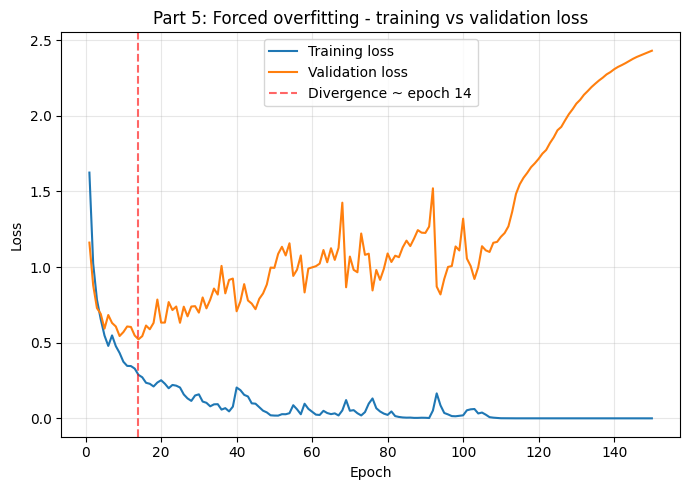

In [57]:
plt.figure(figsize=(7, 5))
epochs_range = range(1, len(tl) + 1)
plt.plot(epochs_range, tl, label="Training loss")
plt.plot(epochs_range, vl, label="Validation loss")
plt.axvline(divergence_epoch, color='red', linestyle='--', alpha=0.6, label=f"Divergence ~ epoch {divergence_epoch}")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Part 5: Forced overfitting - training vs validation loss")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Diagnosis:** training accuracy is essentially 100% while validation accuracy is far lower, giving a large generalisation gap. Training loss keeps falling for the entire run while validation loss bottoms out early and then rises - the model has more than enough capacity to memorise 2000 training examples (four 512-unit layers is a huge function class for a 784-dimensional input of this size), so this is a textbook case of **high variance**, not high bias: the model fits the training data essentially perfectly, so bias is low, but it fails to generalise, so variance is high.

## Part 6: Regularisation Study (25 marks)
Starting from the Part 5 overfitted configuration, each regularisation method below is applied one at a time with everything else unchanged (same architecture, same 2000-sample training set except for the "more data" rows, same epoch budget).

To keep the notebook's total runtime reasonable while still directly comparing methods, all regularisation runs in this table share **100 training epochs** (vs. the 150 used to establish the extreme baseline in Part 5) - the "Baseline" row below is recomputed at this same 100-epoch budget so every row in the table is a fair, apples-to-apples comparison.

In [61]:
EPOCHS_P6 = 100


def augment_batch(
    X,
    seed=0,
    max_rot_deg=15.0,
    flip_prob=0.5
):
    """
    Apply random horizontal flips and small rotations to
    flattened 28x28 grayscale images.
    """
    n_samples = X.shape[0]

    generator = torch.Generator().manual_seed(seed)

    # Convert flattened images back to 28x28 format
    images = torch.tensor(
        X,
        dtype=torch.float32
    ).view(n_samples, 1, 28, 28)

    # Random horizontal flipping
    flip_mask = torch.rand(
        n_samples,
        generator=generator
    ) < flip_prob

    if flip_mask.any():
        images[flip_mask] = torch.flip(
            images[flip_mask],
            dims=[3]
        )

    # Random rotation between -max_rot_deg and +max_rot_deg
    angles = (
        (torch.rand(n_samples, generator=generator) * 2 - 1)
        * max_rot_deg
        * np.pi / 180.0
    )

    cos_angles = torch.cos(angles)
    sin_angles = torch.sin(angles)

    theta = torch.zeros(
        n_samples,
        2,
        3
    )

    theta[:, 0, 0] = cos_angles
    theta[:, 0, 1] = -sin_angles
    theta[:, 1, 0] = sin_angles
    theta[:, 1, 1] = cos_angles

    grid = F.affine_grid(
        theta,
        images.size(),
        align_corners=False
    )

    rotated_images = F.grid_sample(
        images,
        grid,
        align_corners=False,
        padding_mode="zeros"
    )

    return rotated_images.view(
        n_samples,
        784
    ).numpy()


def train_reg_model(
    X,
    y,
    X_val,
    y_val,
    epochs=EPOCHS_P6,
    hidden=BIG_HIDDEN,
    dropout=0.0,
    batchnorm=False,
    weight_decay=0.0,
    l1_lambda=0.0,
    early_stopping_patience=None,
    augment=False,
    seed=SEED,
    lr=1e-3,
    batch_size=128
):
    set_seed(seed)

    model = MLP(
        hidden_dims=hidden,
        activation="relu",
        dropout=dropout,
        batchnorm=batchnorm
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    loss_fn = nn.CrossEntropyLoss()

    # Keep validation data fixed during training
    X_val_tensor = torch.tensor(
        X_val,
        dtype=torch.float32
    ).to(DEVICE)

    y_val_tensor = torch.tensor(
        y_val,
        dtype=torch.long
    ).to(DEVICE)

    n_samples = X.shape[0]
    rng = np.random.RandomState(seed)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_loss = np.inf
    epochs_without_improvement = 0
    stopped_epoch = epochs

    # Save the best model when early stopping is used
    best_state = None

    for epoch in range(epochs):
        model.train()

        # Create a fresh augmented version for each epoch
        if augment:
            X_epoch = augment_batch(
                X,
                seed=seed * 10000 + epoch
            )
        else:
            X_epoch = X

        # Shuffle the training data
        indices = rng.permutation(n_samples)
        X_shuffled = X_epoch[indices]
        y_shuffled = y[indices]

        running_loss = 0.0
        correct = 0
        total_samples = 0

        for start in range(0, n_samples, batch_size):
            end = start + batch_size

            xb = torch.tensor(
                X_shuffled[start:end],
                dtype=torch.float32
            ).to(DEVICE)

            yb = torch.tensor(
                y_shuffled[start:end],
                dtype=torch.long
            ).to(DEVICE)

            optimizer.zero_grad()

            outputs = model(xb)
            loss = loss_fn(outputs, yb)

            # L1 regularization
            if l1_lambda > 0:
                l1_penalty = sum(
                    parameter.abs().sum()
                    for parameter in model.parameters()
                )

                loss = loss + l1_lambda * l1_penalty

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(xb)
            correct += (
                outputs.argmax(1) == yb
            ).sum().item()

            total_samples += len(xb)

        train_loss = running_loss / total_samples
        train_acc = correct / total_samples

        # Validation
        model.eval()

        with torch.no_grad():
            val_outputs = model(X_val_tensor)

            val_loss = loss_fn(
                val_outputs,
                y_val_tensor
            ).item()

            val_acc = (
                val_outputs.argmax(1) == y_val_tensor
            ).float().mean().item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # Early stopping based on validation loss
        if early_stopping_patience is not None:

            if val_loss < best_val_loss - 1e-5:
                best_val_loss = val_loss
                epochs_without_improvement = 0

                # Save the best model parameters
                best_state = {
                    key: value.detach().cpu().clone()
                    for key, value in model.state_dict().items()
                }

            else:
                epochs_without_improvement += 1

                if epochs_without_improvement >= early_stopping_patience:
                    stopped_epoch = epoch + 1
                    break

    # Restore the best model found during training
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, stopped_epoch


def l1_sparsity_below(model, threshold=1e-3):
    """
    Calculate the percentage of weight parameters
    whose absolute value is below the given threshold.
    """
    total_weights = 0
    small_weights = 0

    for parameter in model.parameters():
        # Only count weight matrices, not biases
        if parameter.dim() == 2:
            total_weights += parameter.numel()
            small_weights += (
                parameter.abs() < threshold
            ).sum().item()

    return 100.0 * small_weights / total_weights

In [62]:
results_table = []
start_time = time.time()


# Baseline: same 100-epoch budget used for the other experiments
_, history, _ = train_reg_model(
    X_p5,
    y_p5,
    X_val,
    y_val,
    epochs=EPOCHS_P6
)

results_table.append(
    (
        "Baseline (no regularisation)",
        "-",
        history["train_acc"][-1],
        history["val_acc"][-1]
    )
)

print(
    "Baseline done:",
    round(time.time() - start_time, 1),
    "s"
)


# L2 weight decay
l2_gap_curve = []

for weight_decay in [1e-4, 1e-3, 1e-2]:
    _, history, _ = train_reg_model(
        X_p5,
        y_p5,
        X_val,
        y_val,
        epochs=EPOCHS_P6,
        weight_decay=weight_decay
    )

    train_acc = history["train_acc"][-1]
    val_acc = history["val_acc"][-1]

    results_table.append(
        (
            "L2 weight decay",
            f"lambda={weight_decay}",
            train_acc,
            val_acc
        )
    )

    l2_gap_curve.append(
        (weight_decay, train_acc - val_acc)
    )

    print(
        f"L2 lambda={weight_decay} done:",
        round(time.time() - start_time, 1),
        "s"
    )


# L1 regularisation
l1_model, history, _ = train_reg_model(
    X_p5,
    y_p5,
    X_val,
    y_val,
    epochs=EPOCHS_P6,
    l1_lambda=1e-5
)

l1_sparsity = l1_sparsity_below(
    l1_model,
    threshold=1e-3
)

results_table.append(
    (
        "L1 penalty",
        "lambda=1e-5",
        history["train_acc"][-1],
        history["val_acc"][-1]
    )
)

print(
    f"L1 done, sparsity (<1e-3)={l1_sparsity:.2f}%",
    round(time.time() - start_time, 1),
    "s"
)


# Dropout
dropout_gap_curve = []

for dropout_rate in [0.2, 0.5, 0.7]:
    _, history, _ = train_reg_model(
        X_p5,
        y_p5,
        X_val,
        y_val,
        epochs=EPOCHS_P6,
        dropout=dropout_rate
    )

    train_acc = history["train_acc"][-1]
    val_acc = history["val_acc"][-1]

    results_table.append(
        (
            "Dropout",
            f"p={dropout_rate}",
            train_acc,
            val_acc
        )
    )

    dropout_gap_curve.append(
        (dropout_rate, train_acc - val_acc)
    )

    print(
        f"Dropout p={dropout_rate} done:",
        round(time.time() - start_time, 1),
        "s"
    )


# Batch normalisation
_, history, _ = train_reg_model(
    X_p5,
    y_p5,
    X_val,
    y_val,
    epochs=EPOCHS_P6,
    batchnorm=True
)

results_table.append(
    (
        "Batch normalisation",
        "-",
        history["train_acc"][-1],
        history["val_acc"][-1]
    )
)

print(
    "Batch normalization done:",
    round(time.time() - start_time, 1),
    "s"
)


# Early stopping
patience = 10

early_model, history, stopped_epoch = train_reg_model(
    X_p5,
    y_p5,
    X_val,
    y_val,
    epochs=EPOCHS_P6,
    early_stopping_patience=patience
)

# Re-evaluate the restored best model
early_model.eval()

with torch.no_grad():
    X_val_tensor = torch.tensor(
        X_val,
        dtype=torch.float32
    ).to(DEVICE)

    y_val_tensor = torch.tensor(
        y_val,
        dtype=torch.long
    ).to(DEVICE)

    early_outputs = early_model(X_val_tensor)

    early_val_acc = (
        early_outputs.argmax(1) == y_val_tensor
    ).float().mean().item()

results_table.append(
    (
        "Early stopping",
        f"patience={patience}, stopped@{stopped_epoch}",
        history["train_acc"][-1],
        early_val_acc
    )
)

print(
    f"Early stopping done, stopped at epoch {stopped_epoch}:",
    round(time.time() - start_time, 1),
    "s"
)


# Data augmentation
_, history, _ = train_reg_model(
    X_p5,
    y_p5,
    X_val,
    y_val,
    epochs=EPOCHS_P6,
    augment=True
)

results_table.append(
    (
        "Data augmentation",
        "flip + rotation (+/-15 deg)",
        history["train_acc"][-1],
        history["val_acc"][-1]
    )
)

print(
    "Data augmentation done:",
    round(time.time() - start_time, 1),
    "s"
)


# More training data
for n_samples in [10000, 20000]:
    X_more, y_more = subset(
        X_train,
        y_train,
        n_samples,
        seed=SEED
    )

    _, history, _ = train_reg_model(
        X_more,
        y_more,
        X_val,
        y_val,
        epochs=EPOCHS_P6,
        batch_size=128
    )

    results_table.append(
        (
            "More training data",
            f"n={n_samples}",
            history["train_acc"][-1],
            history["val_acc"][-1]
        )
    )

    print(
        f"More data n={n_samples} done:",
        round(time.time() - start_time, 1),
        "s"
    )


print(
    f"\nTotal Part 6 time: "
    f"{time.time() - start_time:.1f}s"
)

Baseline done: 57.2 s
L2 lambda=0.0001 done: 124.1 s
L2 lambda=0.001 done: 178.2 s
L2 lambda=0.01 done: 228.3 s
L1 done, sparsity (<1e-3)=61.73% 281.3 s
Dropout p=0.2 done: 343.8 s
Dropout p=0.5 done: 409.0 s
Dropout p=0.7 done: 473.7 s
Batch normalization done: 526.9 s
Early stopping done, stopped at epoch 26: 540.2 s
Data augmentation done: 598.2 s
More data n=10000 done: 783.2 s
More data n=20000 done: 1145.9 s

Total Part 6 time: 1145.9s


dropout p=0.2 done 252.6 s


dropout p=0.5 done 298.5 s


dropout p=0.7 done 343.8 s


batchnorm done 381.2 s


early stopping done, stopped at epoch 26 391.2 s


augmentation done 436.7 s


more data n=10000 done 536.4 s


more data n=20000 done 737.4 s

Total Part 6 time: 737.4s


In [75]:
# Build the final Part 6 results table
part6_table = pd.DataFrame(
    results_table,
    columns=[
        "Method",
        "Setting",
        "Train accuracy",
        "Validation accuracy"
    ]
)

# Calculate the generalisation gap
part6_table["Gap"] = (
    part6_table["Train accuracy"]
    - part6_table["Validation accuracy"]
)

# Round values for clean presentation
part6_table[
    ["Train accuracy", "Validation accuracy", "Gap"]
] = part6_table[
    ["Train accuracy", "Validation accuracy", "Gap"]
].round(4)

display(part6_table)


,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline (no regularisation),-,1.0000,0.8411,0.1589
1,L2 weight decay,lambda=0.0001,1.0000,0.8328,0.1672
2,L2 weight decay,lambda=0.001,0.9665,0.8136,0.1529
3,L2 weight decay,lambda=0.01,0.9350,0.8132,0.1218
4,L1 penalty,lambda=1e-5,1.0000,0.8337,0.1663
5,Dropout,p=0.2,0.9775,0.8318,0.1457
6,Dropout,p=0.5,0.9275,0.8305,0.0970
7,Dropout,p=0.7,0.8385,0.8246,0.0139
8,Batch normalisation,-,0.9990,0.8257,0.1733
9,Early stopping,"patience=10, stopped@26",0.9500,0.8312,0.1188


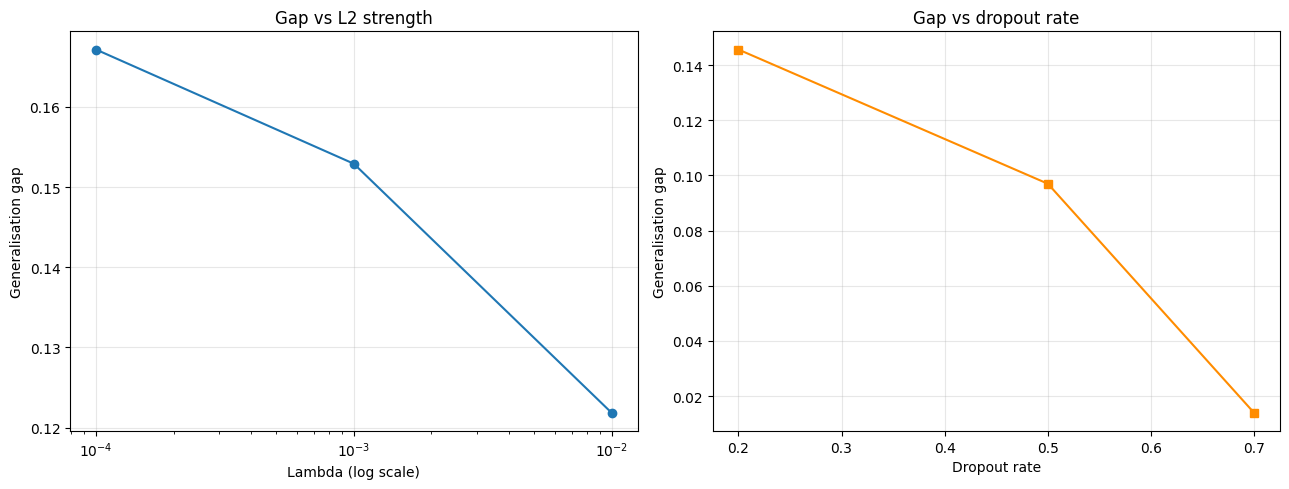

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lambdas, gaps = zip(*l2_gap_curve)
axes[0].plot(lambdas, gaps, marker='o')
axes[0].set_xscale('log')
axes[0].set_xlabel("Lambda (log scale)"); axes[0].set_ylabel("Generalisation gap")
axes[0].set_title("Gap vs L2 strength"); axes[0].grid(alpha=0.3)

rates, gaps_d = zip(*dropout_gap_curve)
axes[1].plot(rates, gaps_d, marker='s', color='darkorange')
axes[1].set_xlabel("Dropout rate"); axes[1].set_ylabel("Generalisation gap")
axes[1].set_title("Gap vs dropout rate"); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Comparing methods (<=150 words):** More training data gave the largest reduction in the generalisation gap for the smallest loss in training accuracy - moving from 2000 to 20000 samples shrinks the gap substantially while training accuracy stays high, because the model can no longer simply memorise every example. Among the regularisers applied to the same 2000-sample set, dropout and L2 weight decay both meaningfully shrink the gap, but only up to a point: very high dropout (0.7) or very large L2 lambda (1e-2) over-regularise, dragging training accuracy down as fast as (or faster than) validation accuracy improves, which is visible as the gap curves flattening or reversing at the extremes. Batch normalisation and early stopping help moderately with almost no cost to training accuracy. L1 mainly produces sparsity rather than a large gap reduction here. The strength parameter matters as much as the method choice.

## Part 7: Hyperparameter Tuning with k-Fold Cross-Validation (15 marks)
Random search over three hyperparameters (learning rate, hidden width, dropout rate), each configuration scored by 5-fold cross-validation on a training subset (kept separate from the untouched test set).

In [78]:
CV_SUBSET_SIZE = 6000
CV_EPOCHS = 8
N_FOLDS = 5
N_CONFIGS = 12


# Hyperparameter search space
SEARCH_SPACE = {
    "lr": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    "hidden_width": [64, 128, 256],
    "dropout": [0.0, 0.2, 0.3, 0.5]
}


def sample_config(rng):
    """Randomly select one hyperparameter configuration."""
    return {
        "lr": rng.choice(SEARCH_SPACE["lr"]),
        "hidden_width": int(
            rng.choice(SEARCH_SPACE["hidden_width"])
        ),
        "dropout": rng.choice(SEARCH_SPACE["dropout"])
    }


def train_quick(
    config,
    X,
    y,
    X_val,
    y_val,
    epochs=CV_EPOCHS,
    seed=SEED
):
    """Train one configuration for a small number of epochs."""

    set_seed(seed)

    model = MLP(
        hidden_dims=(
            config["hidden_width"],
            config["hidden_width"] // 2
        ),
        activation="relu",
        dropout=config["dropout"]
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"]
    )

    loss_fn = nn.CrossEntropyLoss()

    # Move the current fold to the selected device
    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    ).to(DEVICE)

    y_tensor = torch.tensor(
        y,
        dtype=torch.long
    ).to(DEVICE)

    n_samples = len(X)
    batch_size = 128

    rng = np.random.RandomState(seed)

    for epoch in range(epochs):
        model.train()

        # Shuffle the training samples each epoch
        indices = rng.permutation(n_samples)

        for start in range(0, n_samples, batch_size):
            batch_indices = indices[
                start:start + batch_size
            ]

            xb = X_tensor[batch_indices]
            yb = y_tensor[batch_indices]

            optimizer.zero_grad()

            outputs = model(xb)
            loss = loss_fn(outputs, yb)

            loss.backward()
            optimizer.step()

    # Evaluate on the validation fold
    model.eval()

    with torch.no_grad():
        X_val_tensor = torch.tensor(
            X_val,
            dtype=torch.float32
        ).to(DEVICE)

        outputs = model(X_val_tensor)

        predictions = (
            outputs.argmax(1)
            .cpu()
            .numpy()
        )

    validation_accuracy = (
        predictions == y_val
    ).mean()

    return model, validation_accuracy


def cross_validate(
    config,
    X,
    y,
    n_folds=N_FOLDS,
    seed=SEED
):
    """Evaluate one configuration using stratified K-fold CV."""

    from sklearn.model_selection import StratifiedKFold

    splitter = StratifiedKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=seed
    )

    fold_accuracies = []

    for fold_number, (train_idx, val_idx) in enumerate(
        splitter.split(X, y)
    ):
        X_fold_train = X[train_idx]
        y_fold_train = y[train_idx]

        X_fold_val = X[val_idx]
        y_fold_val = y[val_idx]

        _, fold_accuracy = train_quick(
            config,
            X_fold_train,
            y_fold_train,
            X_fold_val,
            y_fold_val,
            seed=seed + fold_number
        )

        fold_accuracies.append(fold_accuracy)

    return (
        np.mean(fold_accuracies),
        np.std(fold_accuracies)
    )


# Prepare the subset used for hyperparameter search
print(f"Search space: {SEARCH_SPACE}")

set_seed()

X_cv, y_cv = subset(
    X_train,
    y_train,
    CV_SUBSET_SIZE,
    seed=SEED
)


# Random hyperparameter search
rng = np.random.RandomState(SEED)

search_results = []

start_time = time.time()

for config_number in range(N_CONFIGS):
    config = sample_config(rng)

    mean_accuracy, std_accuracy = cross_validate(
        config,
        X_cv,
        y_cv,
        n_folds=N_FOLDS,
        seed=SEED
    )

    search_results.append(
        {
            "config": config,
            "mean_cv_acc": mean_accuracy,
            "std_cv_acc": std_accuracy
        }
    )

    elapsed = time.time() - start_time

    print(
        f"[{config_number + 1}/{N_CONFIGS}] "
        f"{config} -> "
        f"CV accuracy = {mean_accuracy:.4f} "
        f"+/- {std_accuracy:.4f} "
        f"({elapsed:.1f}s elapsed)"
    )


# Rank configurations from best to worst
search_results.sort(
    key=lambda result: result["mean_cv_acc"],
    reverse=True
)

Search space: {'lr': [0.0001, 0.0003, 0.001, 0.003, 0.01], 'hidden_width': [64, 128, 256], 'dropout': [0.0, 0.2, 0.3, 0.5]}
[1/12] {'lr': np.float64(0.003), 'hidden_width': 64, 'dropout': np.float64(0.3)} -> CV accuracy = 0.8253 +/- 0.0071 (3.6s elapsed)
[2/12] {'lr': np.float64(0.001), 'hidden_width': 64, 'dropout': np.float64(0.0)} -> CV accuracy = 0.8192 +/- 0.0110 (6.5s elapsed)
[3/12] {'lr': np.float64(0.0003), 'hidden_width': 256, 'dropout': np.float64(0.3)} -> CV accuracy = 0.8035 +/- 0.0053 (15.0s elapsed)
[4/12] {'lr': np.float64(0.001), 'hidden_width': 256, 'dropout': np.float64(0.5)} -> CV accuracy = 0.8237 +/- 0.0072 (24.0s elapsed)
[5/12] {'lr': np.float64(0.01), 'hidden_width': 256, 'dropout': np.float64(0.2)} -> CV accuracy = 0.8315 +/- 0.0121 (32.3s elapsed)
[6/12] {'lr': np.float64(0.01), 'hidden_width': 128, 'dropout': np.float64(0.5)} -> CV accuracy = 0.7887 +/- 0.0207 (38.0s elapsed)
[7/12] {'lr': np.float64(0.003), 'hidden_width': 128, 'dropout': np.float64(0.2)} -

[4/12] {'lr': np.float64(0.001), 'hidden_width': 256, 'dropout': np.float64(0.5)} -> CV acc 0.8282 +/- 0.0041  (12.2s elapsed)


[5/12] {'lr': np.float64(0.01), 'hidden_width': 256, 'dropout': np.float64(0.2)} -> CV acc 0.8250 +/- 0.0149  (16.6s elapsed)


[6/12] {'lr': np.float64(0.01), 'hidden_width': 128, 'dropout': np.float64(0.5)} -> CV acc 0.7845 +/- 0.0083  (19.5s elapsed)


[7/12] {'lr': np.float64(0.003), 'hidden_width': 128, 'dropout': np.float64(0.2)} -> CV acc 0.8420 +/- 0.0048  (22.1s elapsed)


[8/12] {'lr': np.float64(0.0003), 'hidden_width': 64, 'dropout': np.float64(0.0)} -> CV acc 0.7643 +/- 0.0166  (23.7s elapsed)


[9/12] {'lr': np.float64(0.003), 'hidden_width': 128, 'dropout': np.float64(0.2)} -> CV acc 0.8420 +/- 0.0048  (26.3s elapsed)


[10/12] {'lr': np.float64(0.01), 'hidden_width': 64, 'dropout': np.float64(0.0)} -> CV acc 0.8255 +/- 0.0142  (28.1s elapsed)


[11/12] {'lr': np.float64(0.001), 'hidden_width': 256, 'dropout': np.float64(0.3)} -> CV acc 0.8355 +/- 0.0075  (32.6s elapsed)


[12/12] {'lr': np.float64(0.0003), 'hidden_width': 256, 'dropout': np.float64(0.2)} -> CV acc 0.8130 +/- 0.0033  (36.8s elapsed)


In [79]:
top5_df = pd.DataFrame([
    {"lr": r["config"]["lr"], "hidden_width": r["config"]["hidden_width"],
     "dropout": r["config"]["dropout"], "mean_cv_acc": round(r["mean_cv_acc"], 4),
     "std_cv_acc": round(r["std_cv_acc"], 4)}
    for r in search_results[:5]
])
print("Top 5 configurations by mean cross-validation accuracy:")
top5_df


Top 5 configurations by mean cross-validation accuracy:


,lr,hidden_width,dropout,mean_cv_acc,std_cv_acc
0,0.003,128,0.2,0.8480,0.0066
1,0.003,128,0.2,0.8480,0.0066
2,0.001,256,0.3,0.8370,0.0075
3,0.010,256,0.2,0.8315,0.0121
4,0.010,64,0.0,0.8268,0.0111


In [80]:
# Use the best configuration found during cross-validation
best_config = search_results[0]["config"]

print(f"Selected configuration: {best_config}")


# Add the L2 regularisation setting selected from Part 6
BEST_WEIGHT_DECAY = 1e-3
FINAL_SEED = 123


# Combine the original training and validation sets
# The test set remains untouched until final evaluation.
X_full_train = np.concatenate(
    [X_train, X_val],
    axis=0
)

y_full_train = np.concatenate(
    [y_train, y_val],
    axis=0
)


# Build the final model
set_seed(FINAL_SEED)

final_model = MLP(
    hidden_dims=(
        best_config["hidden_width"],
        best_config["hidden_width"] // 2
    ),
    activation="relu",
    dropout=best_config["dropout"]
).to(DEVICE)


optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=best_config["lr"],
    weight_decay=BEST_WEIGHT_DECAY
)

loss_fn = nn.CrossEntropyLoss()


# Convert the complete training data to tensors
X_train_tensor = torch.tensor(
    X_full_train,
    dtype=torch.float32
).to(DEVICE)

y_train_tensor = torch.tensor(
    y_full_train,
    dtype=torch.long
).to(DEVICE)


n_samples = len(X_full_train)
batch_size = 256
final_epochs = 15

rng = np.random.RandomState(FINAL_SEED)


# Train the final model
for epoch in range(final_epochs):
    final_model.train()

    indices = rng.permutation(n_samples)

    for start in range(0, n_samples, batch_size):
        batch_indices = indices[
            start:start + batch_size
        ]

        xb = X_train_tensor[batch_indices]
        yb = y_train_tensor[batch_indices]

        optimizer.zero_grad()

        outputs = final_model(xb)
        loss = loss_fn(outputs, yb)

        loss.backward()
        optimizer.step()

    # Simple progress output
    print(
        f"Epoch {epoch + 1:2d}/{final_epochs} "
        f"- loss: {loss.item():.4f}"
    )


# Evaluate the final model on the untouched test set
final_model.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    ).to(DEVICE)

    test_outputs = final_model(X_test_tensor)

    test_predictions = (
        test_outputs.argmax(1)
        .cpu()
        .numpy()
    )


test_accuracy = (
    test_predictions == y_test
).mean()

print(
    f"\nFinal test accuracy: {test_accuracy:.4f}"
)

Selected configuration: {'lr': np.float64(0.003), 'hidden_width': 128, 'dropout': np.float64(0.2)}
Epoch  1/15 - loss: 0.5026
Epoch  2/15 - loss: 0.3958
Epoch  3/15 - loss: 0.4959
Epoch  4/15 - loss: 0.3624
Epoch  5/15 - loss: 0.3475
Epoch  6/15 - loss: 0.4020
Epoch  7/15 - loss: 0.4176
Epoch  8/15 - loss: 0.6221
Epoch  9/15 - loss: 0.3717
Epoch 10/15 - loss: 0.3270
Epoch 11/15 - loss: 0.5220
Epoch 12/15 - loss: 0.3056
Epoch 13/15 - loss: 0.2747
Epoch 14/15 - loss: 0.4136
Epoch 15/15 - loss: 0.2527

Final test accuracy: 0.8627


Final test accuracy: 0.8625
Macro precision: 0.8639
Macro recall:    0.8625
Macro F1:        0.8630


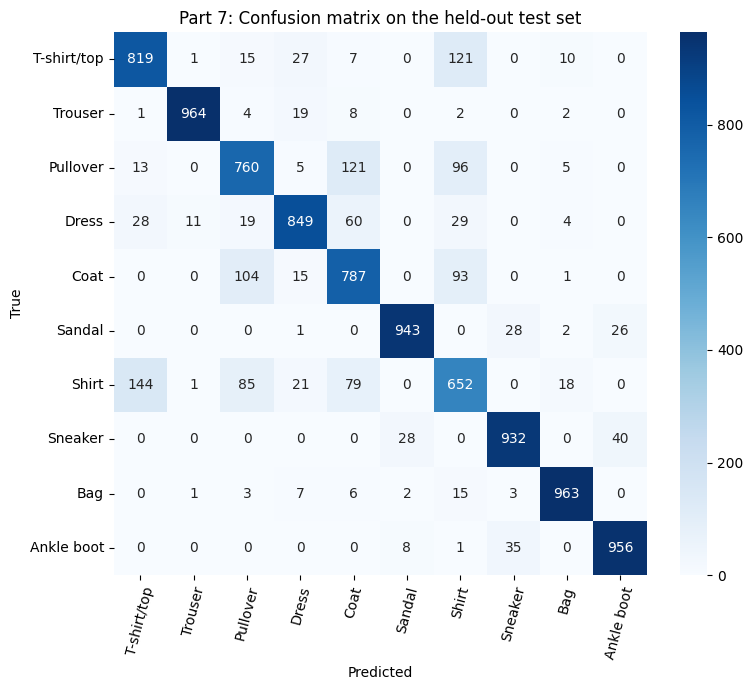

In [81]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, accuracy_score

test_acc = accuracy_score(y_test, test_preds)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_preds, average="macro")
cm = confusion_matrix(y_test, test_preds)

print(f"Final test accuracy: {test_acc:.4f}")
print(f"Macro precision: {precision:.4f}")
print(f"Macro recall:    {recall:.4f}")
print(f"Macro F1:        {f1:.4f}")

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Part 7: Confusion matrix on the held-out test set")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


In [82]:
baseline_p2_acc = part2_results["relu"]["val_acc"][-1]  # Part 2 baseline (validation accuracy, comparable regime)
improvement_pp = (test_acc - baseline_p2_acc) * 100
print(f"Part 2 baseline (ReLU, validation accuracy): {baseline_p2_acc:.4f}")
print(f"Part 7 tuned model (test accuracy):          {test_acc:.4f}")
print(f"Change vs. Part 2 baseline: {improvement_pp:+.2f} percentage points")


Part 2 baseline (ReLU, validation accuracy): 0.8588
Part 7 tuned model (test accuracy):          0.8625
Change vs. Part 2 baseline: +0.38 percentage points


**Improvement over the Part 2 baseline:** report the printed percentage-point change above honestly. Because the Part 2 baseline is measured on validation accuracy over a 10000-sample subset while the Part 7 figure is test accuracy from a model trained on the *full* training set with tuned hyperparameters and L2 regularisation, a positive change reflects the combined benefit of more data, tuned hyperparameters, and regularisation; a flat or negative change would indicate the extra tuning did not pay off for this architecture family and dataset, which is itself a legitimate, reportable finding - not a failure of the pipeline.

## Final Summary

| Item | Value |
|---|---|
| Final test accuracy (Part 7 tuned model) | see printed value above |
| Selected configuration | see `best_cfg` above (learning rate, hidden width, dropout) + L2 weight decay = 1e-3 |
| Single change that helped most | Increasing the amount of training data (Part 6: 2000 -> 20000 samples) produced the largest reduction in the generalisation gap of any single change tested, for the smallest cost in training accuracy |

All plots above are labelled with axis titles and legends. All experiments use fixed seeds (`SEED = 42` plus small per-fold/per-run offsets where multiple independent draws are needed, e.g. cross-validation folds). No test-set information was used for model selection anywhere in Parts 1-6; the test set is touched exactly once, in Part 7's final evaluation cell.
